<a href="https://colab.research.google.com/github/vifirsanova/ML-2026-pt-2/blob/main/advanced/1_recommender_systems/RecSys_tutor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Рекомендательные системы

> Я адаптировала материал [отсюда](https://developers.google.com/machine-learning/recommendation)

## 1. Интуитивное описание задачи и матрица признаков

### Что такое рекомендательные системы?
Рекомендательные системы помогают пользователям находить релевантный контент в больших каталогах. Два основных типа рекомендаций:
- **Рекомендации на главной странице** — персонализированы под пользователя
- **Рекомендации похожих товаров** — основаны на текущем просматриваемом объекте

### Терминология

**Items (documents)**: то, что система рекомендует

Примеры:
- **Приложения** Google Play
- **Видео** на YouTube

**Query (context)**: информация, на основе которой система даёт рекомендации

Из чего выстраиваются запросы:
- Инфрмация о пользователе (id, взаимодействующие сущности)
- Контекст (время суток, девайс)

**Embedding**: мэппинг дискретного набора признаков (набор запросов, набор сущностей) на векторное пространство

> Для разработки RecSys часто обучают эмбеддинговые модели, матрицы queries x items

### Архитектура рекомендательной системы
Типичная архитектура состоит из трех этапов:
1. **Генерация кандидатов (Candidate Generation)** — из всего каталога (миллионы объектов) выбирается небольшое подмножество (сотни/тысячи сущностей)
2. **Ранжирование (Scoring)** — более точная модель оценивает кандидатов и выбирает топ-N (десятки сущностей)
3. **Переранжирование (Re-ranking)** — учитываются дополнительные факторы: свежесть, разнообразие, бизнес-ограничения

### Матрица признаков
В основе многих подходов лежит **матрица признаков**:
- Строки — объекты (треки, фильмы, товары)
- Столбцы — признаки (жанры, исполнители, аудиохарактеристики)
- Значения — наличие/выраженность признака

> Для пользователя также строится вектор признаков на основе его истории взаимодействий и профиля

**Пример для Spotify:** матрица треков с признаками: `danceability`, `energy`, `acousticness`, `valence`, жанр, исполнитель

## 2. Пример на Spotify: обработка данных

### Датасет
Используем датасет треков Spotify с аудиохарактеристиками

In [ ]:
!wget https://raw.githubusercontent.com/Demibolt007/Spotify-Streaming-Insights-2010-2019/refs/heads/main/Spotify%20Dataset.csv -O spotify_tracks.csv

--2026-04-01 19:04:19--  https://raw.githubusercontent.com/Demibolt007/Spotify-Streaming-Insights-2010-2019/refs/heads/main/Spotify%20Dataset.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 78424 (77K) [text/plain]
Saving to: ‘spotify_tracks.csv’

spotify_tracks.csv  100%[===================>]  76.59K  --.-KB/s    in 0.01s   

2026-04-01 19:04:19 (5.25 MB/s) - ‘spotify_tracks.csv’ saved [78424/78424]



In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# 1. Загрузка данных
df = pd.read_csv('spotify_tracks.csv')

# 2. Отбор числовых признаков (аудиохарактеристики)
feature_cols = ['Danceability', 'Energy', 'Speechiness',
                'Acousticness', 'Liveness', 'Valence']

# 3. Очистка от пропусков
df = df.dropna(subset=feature_cols)

# 4. Масштабирование — критически важно для методов, основанных на расстояниях
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_cols])

### Масштабирование
- **StandardScaler** — центрирует и приводит к единичной дисперсии (для KMeans, PCA)
- **MinMaxScaler** — приводит к диапазону [0,1] (для нейросетей)

### StandardScaler (Z-нормализация)

**Формула:**
$$ z = \frac{x - \mu}{\sigma} $$

Где:
- $ x $ — исходное значение признака
- $ \mu $ — **среднее арифметическое** всех значений этого признака в выборке
- $ \sigma $ — **стандартное отклонение** (квадратный корень из дисперсии) значений этого признака

**Результат:**
- Новое среднее = 0
- Новое стандартное отклонение = 1
- Диапазон значений: теоретически от $-\infty$ до $+\infty$ (на практике обычно от -3 до +3)

**Пример:**  
Если у вас признак `[1, 2, 3, 4, 5]`:
- $ \mu = 3 $
- $ \sigma \approx 1.41 $
- Первое значение: $ (1 - 3) / 1.41 = -1.41 $

---

### MinMaxScaler (Нормализация в диапазон)

**Формула (стандартная, в диапазон [0, 1]):**
$$ x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}} $$

Где:
- $ x $ — исходное значение
- $ x_{min} $ — минимальное значение признака в выборке
- $ x_{max} $ — максимальное значение признака в выборке

**Результат:**
- Все значения строго лежат в интервале [0, 1]
- Сохраняется форма распределения (относительные расстояния между точками)

**Пример:**  
Для того же набора `[1, 2, 3, 4, 5]`:
- $ x_{min} = 1 $, $ x_{max} = 5 $, размах = 4
- Первое значение: $ (1 - 1) / 4 = 0 $
- Третье значение: $ (3 - 1) / 4 = 0.5 $
- Пятое значение: $ (5 - 1) / 4 = 1 $



## 3. Методы: кластеризация для генерации кандидатов


### KMeans для группировки похожих треков
Кластеризация позволяет сгруппировать похожие треки, чтобы рекомендовать треки из того же кластера.

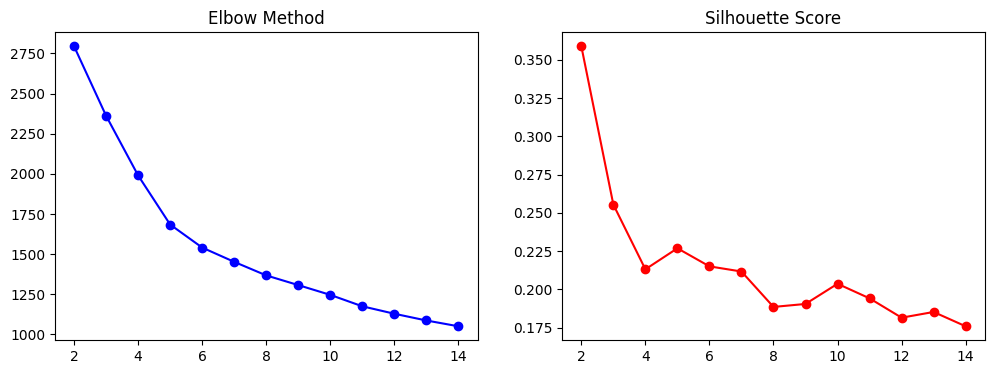

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt

# Подбор оптимального количества кластеров
inertias = []
silhouette_scores = []
K_range = range(2, 15)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Визуализация для выбора k
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_range, inertias, 'bo-')
ax1.set_title('Elbow Method')
ax2.plot(K_range, silhouette_scores, 'ro-')
ax2.set_title('Silhouette Score')
plt.show()

# Обучение финальной модели
optimal_k = 8  # выбирается по графикам
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

### Метрики качества кластеризации
- **Silhouette Score** — измеряет, насколько объект похож на свой кластер по сравнению с соседними. Диапазон [-1, 1], чем выше, тем лучше
- **Davies-Bouldin Index** — среднее сходство между кластерами. Чем меньше, тем лучше
- **Inertia** — сумма квадратов расстояний до центроидов. Используется для метода локтя

### **Inertia (инерция) — сумма квадратов внутрикластерных расстояний**

**Формула:**
$$ \text{Inertia} = \sum_{i=1}^{n} \sum_{j=1}^{k} w_{ij} \cdot ||x_i - \mu_j||^2 $$

Где:
- $ n $ — количество объектов
- $ k $ — количество кластеров
- $ x_i $ — i-й объект
- $ \mu_j $ — центр (центроид) j-го кластера
- $ w_{ij} = 1 $, если объект i принадлежит кластеру j, иначе 0
- $ ||x_i - \mu_j||^2 $ — квадрат евклидова расстояния

Инерция показывает, насколько объекты "кучно" расположены вокруг центров своих кластеров. **Чем меньше инерция, тем лучше** (кластеры более компактны)

Инерция всегда уменьшается с ростом k, поэтому для выбора оптимального k используют **метод локтя** (Elbow Method) — ищут точку резкого замедления падения инерции

### Метод локтя (Elbow Method)

Метод локтя помогает выбрать оптимальное количество кластеров $ k $, анализируя график **зависимости инерции от k**

1. Запускаем KMeans для $ k = 1, 2, 3, ..., K_{max} $
2. Для каждого $ k $ вычисляем **инерцию**
3. Строим график: по оси X — $ k $, по оси Y — инерция

#### Почему "локоть"?

**Инерция всегда уменьшается** с ростом \( k \):
- Добавляя новый кластер, мы делаем объекты "ближе" к своим центроидам
- При $ k = n $ (каждый объект — свой кластер) инерция = 0

Однако скорость уменьшения инерции **замедляется** после некоторого $ k $:

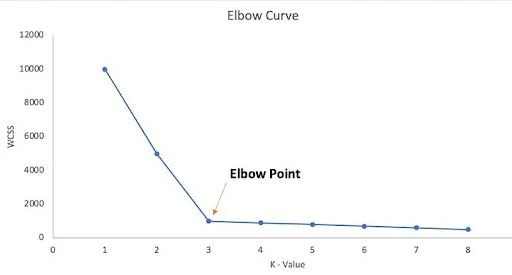

**Оптимальный $ k $ находится в точке "локтя"** — где кривая резко меняет угол наклона

### Математическое объяснение

Уменьшение инерции при добавлении нового кластера:

$$
\Delta \text{Inertia}(k) = \text{Inertia}(k) - \text{Inertia}(k+1)
$$

- **При малых $ k $**: $ \Delta \text{Inertia} $ велико — каждый новый кластер сильно улучшает компактность
- **При больших $ k $**: $ \Delta \text{Inertia} $ мало — улучшение незначительно, начинается **переобучение** (кластеры дробят шум, а не реальные группы)

"Локоть" — точка, где выгода от добавления кластера становится маленькой

### **Silhouette Score**

**Формула для одного объекта i:**
$$
s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
$$

Где:
- $ a(i) $ — **среднее расстояние** от объекта i до **других объектов в СВОЕМ** кластере (внутрикластерное расстояние)  
  *(чем меньше, тем лучше — объект похож на соседей)*

- $ b(i) $ — **среднее расстояние** от объекта i до объектов в **БЛИЖАЙШЕМ СОСЕДНЕМ** кластере (минимальное среднее расстояние до другого кластера)  
  *(чем больше, тем лучше — кластеры хорошо разделены)*

**Итоговый силуэт-скор:**  
$$ \text{Silhouette} = \frac{1}{n} \sum_{i=1}^{n} s(i) $$

**Интерпретация:**
- **Близко к +1** — объект хорошо сгруппирован (далеко от соседних кластеров)
- **Около 0** — объект на границе между кластерами
- **Отрицательное** — объект, вероятно, попал не в свой кластер

**Для выбора k:** выбирают то k, где силуэт-скор **максимален**

### Функция рекомендации на основе кластера

In [ ]:
def recommend_by_cluster(track_id, df, n_recommendations=5):
    cluster = df.loc[track_id, 'cluster']
    cluster_tracks = df[df['cluster'] == cluster]
    return cluster_tracks.drop(track_id).head(n_recommendations)

In [ ]:
df.sample()

,Song,Artist,Genre,Year,Streams,In Spotify Playlists,On Spotify Charts,Billboard Rankings,In Apple Playlists,On Apple Charts,...,Mode,Energy,Danceability,Liveness,Valence,Duration,Acousticness,Speechiness,Popularity,cluster
167,Focus,Ariana Grande,Dance Pop,2015,404887295,3218,401,15,13965,79,...,Major,88,67,44,79,211,27,24,66,4


In [ ]:
recommend_by_cluster(167, df)

,Song,Artist,Genre,Year,Streams,In Spotify Playlists,On Spotify Charts,Billboard Rankings,In Apple Playlists,On Apple Charts,...,Mode,Energy,Danceability,Liveness,Valence,Duration,Acousticness,Speechiness,Popularity,cluster
28,Animal,Neon Trees,Indie Pop,2010,394030335,3045,158,276,35889,68,...,Minor,83,48,38,74,212,0,4,65,4
30,Antisocial (with Travis Scott),Ed Sheeran,Pop,2019,1145727611,10565,94,94,13115,94,...,Major,82,72,36,91,162,13,5,78,4
41,Bang Bang,Jessie J,Australian Pop,2015,317726339,2468,133,51,24307,51,...,Minor,75,71,38,73,199,27,9,61,4
46,Been You,Justin Bieber,Canadian Pop,2015,305650299,2350,383,29,11599,29,...,Minor,78,74,32,86,199,2,7,60,4
52,Blah Blah Blah (feat. 3OH!3),Kesha,Dance Pop,2010,338422004,2605,132,383,24647,71,...,Minor,84,75,42,52,172,8,12,62,4


## 4. Методы: матричная факторизация (Matrix Factorization)

### Принцип работы
Матричная факторизация раскладывает матрицу взаимодействий `A (users × items)` на произведение двух низкоранговых матриц:
- `U (users × d)` — эмбеддинги пользователей
- `V (items × d)` — эмбеддинги объектов

Предсказание: `Â_ij = ⟨U_i, V_j⟩`

Матричная факторизация — это метод **снижения размерности**, который находит скрытые латентные факторы, объясняющие взаимодействия между пользователями и объектами

Дано:
- **Матрица A** размера $ m \times n $ (m пользователей, n объектов)
- Элементы $ A_{ij} $ — взаимодействия (оценки, клики, покупки, просмотры)

Задача:
Найти две матрицы **U** и **V** такие, что:

$$ A \approx U \cdot V^T $$

Где:
- **U** — матрица $ m \times d $ (эмбеддинги пользователей)
- **V** — матрица $ n \times d $ (эмбеддинги объектов)
- $ d \ll \min(m, n) $ — количество латентных факторов

---

### Формула предсказания

$$ \hat{A}_{ij} = \langle U_i, V_j \rangle = \sum_{f=1}^{d} U_{if} \cdot V_{jf} $$

- $ \hat{A}_{ij} $ — предсказанное значение для пользователя i и объекта j
- $ \langle U_i, V_j \rangle $ — скалярное произведение векторов
- $ U_i $ — i-я строка матрицы U (вектор длины d)
- $ V_j $ — j-я строка матрицы V (вектор длины d)

**Что означает скалярное произведение:**

$$
\hat{A}_{ij} = U_{i1}\cdot V_{j1} + U_{i2}\cdot V_{j2} + ... + U_{id}\cdot V_{jd}
$$

Каждое слагаемое — вклад одного латентного фактора:
- $ U_{if} $ — насколько пользователь i "любит" фактор f
- $ V_{jf} $ — насколько объект j "обладает" фактором f

### WALS (Weighted Alternating Least Squares)
- Попеременно фиксирует U и оптимизирует V, затем наоборот
- Учитывает как наблюдаемые, так и ненаблюдаемые взаимодействия
- Легко распараллеливается

In [ ]:
!pip install implicit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 2.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for implicit: filename=implicit-0.7.2-cp312-cp312-linux_x86_64.whl size=933264 sha256=34197b745b7da4d77259bd9fccbe501bc8773b0f4682e611321c7fd6cc313ca6
  Stored in directory: /root/.cache/pip/wheels/b2/00/4f/9ff8af07a0a53ac6007ea5d739da19cfe147a2df542b6899f8
Successfully built implicit


> В классическом датасете Spotify (как и в большинстве открытых датасетов) есть только треки с их аудиохарактеристиками, но нет пользовательских взаимодействий

WALS требует матрицу "пользователь × объект" (user-item interactions). Здесь мы создадим синтетические пользовательские взаимодействия на основе треков

#### Создаем N искусственных пользователей, где каждый "пользователь" — это набор треков, которые он "прослушал". Можно сгруппировать треки по:

- Жанрам
- Кластерам (полученным из KMeans)
- Случайным образом

In [ ]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
import implicit
from sklearn.preprocessing import StandardScaler

# Загрузка данных

# 1. Создаем кластеры для группировки треков (содержательная основа)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_cols])

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=20, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# 2. Создаем синтетических пользователей
n_users = 100
user_item_matrix = np.zeros((n_users, len(df)))

# Каждый пользователь "слушает" треки из 2-3 случайных кластеров
np.random.seed(42)
for user_id in range(n_users):
    # Выбираем 2-3 кластера для пользователя
    user_clusters = np.random.choice(df['cluster'].unique(),
                                     size=np.random.randint(2, 5),
                                     replace=False)
    # Из этих кластеров выбираем треки
    cluster_tracks = df[df['cluster'].isin(user_clusters)].index
    # Случайно выбираем 10-50 треков
    n_tracks = np.random.randint(10, 51)
    selected_tracks = np.random.choice(cluster_tracks,
                                       size=min(n_tracks, len(cluster_tracks)),
                                       replace=False)
    user_item_matrix[user_id, selected_tracks] = 1

# Создаем sparse матрицу
user_item_sparse = csr_matrix(user_item_matrix)

print(f"Матрица {user_item_sparse.shape}")
print(f"Плотность: {user_item_sparse.nnz / (user_item_sparse.shape[0] * user_item_sparse.shape[1]):.4f}")

Матрица (100, 599)
Плотность: 0.0500


Обучение WALS

In [ ]:
# Обучение ALS (WALS) на синтетических данных
model = implicit.als.AlternatingLeastSquares(
    factors=50,           # размерность эмбеддингов
    regularization=0.01,  # регуляризация
    iterations=20,        # количество итераций
    random_state=42
)

# Обучаем на синтетической матрице
model.fit(user_item_sparse)

# Получаем эмбеддинги треков (item embeddings)
item_embeddings = model.item_factors
print(f"Эмбеддинги треков: {item_embeddings.shape}")

# Получаем эмбеддинги пользователей
user_embeddings = model.user_factors
print(f"Эмбеддинги пользователей: {user_embeddings.shape}")

/usr/local/lib/python3.12/dist-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 2 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


  0%|          | 0/20 [00:00<?, ?it/s]

Эмбеддинги треков: (599, 50)
Эмбеддинги пользователей: (100, 50)


Использование для рекомендаций

In [ ]:
def recommend_tracks_wals(user_id, user_item_matrix, model, df, n=2):
    """Рекомендация треков для пользователя через WALS"""
    recommendations = model.recommend(
        user_id,
        user_item_matrix[user_id],
        N=n
    )
    track_indices = [rec[0] for rec in recommendations]
    return df.iloc[track_indices][['Song', 'Artist', 'cluster']]

# Пример
print(recommend_tracks_wals(0, user_item_sparse, model, df))

                  Song          Artist  cluster
266  Kissing Strangers            DNCE       18
0                    3  Britney Spears       18


| Преимущества | Недостатки |
|--------------|------------|
| Не требует знаний предметной области | Проблема холодного старта |
| Позволяет находить неочевидные связи | Не учитывает контекст |
| Хорошо масштабируется | Сложно добавлять признаки |

## 5. Глубинное обучение: DNN для рекомендаций

### Softmax DNN модель
Рассматривает задачу как многоклассовую классификацию:
- **Вход:** признаки пользователя (история, демография, контекст)
- **Выход:** вероятность взаимодействия с каждым объектом

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

class RecommendationDNN(Model):
    def __init__(self, num_items, embedding_dim=64):
        super().__init__()
        self.user_dense = layers.Dense(128, activation='relu')
        self.user_embedding = layers.Dense(embedding_dim)
        self.item_embedding = layers.Embedding(num_items, embedding_dim)
        self.softmax = layers.Dense(num_items, activation='softmax')

    def call(self, inputs):
        user_features = inputs['user_features']
        user_vec = self.user_embedding(self.user_dense(user_features))
        item_embeddings = self.item_embedding(inputs['item_ids'])
        scores = tf.matmul(user_vec, item_embeddings, transpose_b=True)
        return self.softmax(scores)

### Two-Tower модель
Разделяет обработку пользовательских и объектных признаков:
- **User Tower** — преобразует признаки пользователя в эмбеддинг
- **Item Tower** — преобразует признаки объекта в эмбеддинг
- **Сходство** — вычисляется как косинусное расстояние или скалярное произведение

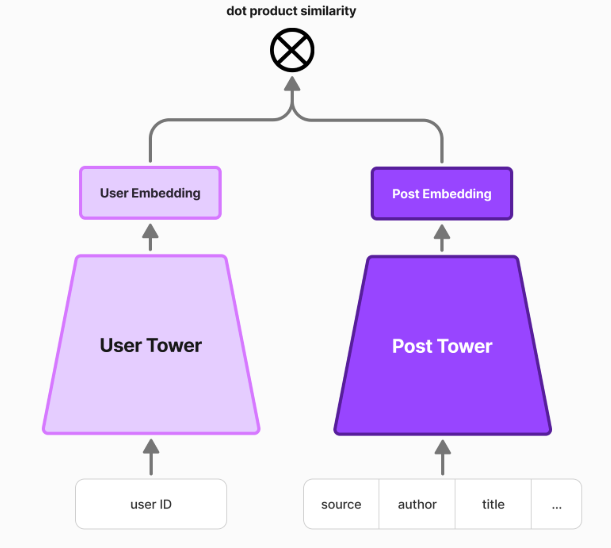

In [ ]:
class TwoTowerModel(Model):
    def __init__(self, embedding_dim=64):
        super().__init__()
        self.user_tower = tf.keras.Sequential([
            layers.Dense(128, activation='relu'),
            layers.Dense(embedding_dim)
        ])
        self.item_tower = tf.keras.Sequential([
            layers.Dense(128, activation='relu'),
            layers.Dense(embedding_dim)
        ])

    def call(self, inputs):
        user_emb = self.user_tower(inputs['user_features'])
        item_emb = self.item_tower(inputs['item_features'])
        similarity = tf.reduce_sum(user_emb * item_emb, axis=1)
        return tf.sigmoid(similarity)

### Negative Sampling
Для ускорения обучения используется сэмплирование негативных примеров:
- Положительные: объекты, с которыми пользователь взаимодействовал
- Отрицательные: случайные объекты из каталога
- Сложные негативные: объекты с высоким скором, но не взаимодействовал

## 6. Retrieval и приближенный поиск

### Способы получения кандидатов
1. **Полный перебор (exhaustive)** — только для небольших каталогов
2. **Предварительный расчет** — для статичных эмбеддингов (например, связанные товары)
3. **Приближенный поиск ближайших соседей (ANN)** — для масштабирования

### Инструменты для ANN
- **ScaNN** (Google)
- **FAISS** (Facebook)
- **Annoy** (Spotify)

In [ ]:
import faiss

# Построение индекса для эмбеддингов треков
embeddings = np.array(df['embedding'].tolist()).astype('float32')
index = faiss.IndexFlatL2(embeddings.shape[1])
index.add(embeddings)

# Поиск ближайших
query_embedding = get_user_embedding(user_id)
distances, indices = index.search(query_embedding.reshape(1, -1), k=10)